# Fine-tuning BERT in Google Colab

Этот ноутбук показывает, как дообучать BERT под разные типы задач на одной GPU в Google Colab.

Мы разберём четыре примера:
1. **Классификация текста**: `glue/sst2`
2. **Sequence labeling / NER**: `conll2003`
3. **Sentence pair classification**: `glue/mrpc`
4. **Extractive QA**: `squad`

В качестве домашнего задания можно взять:
- **Классификация текста**: `imdb` или `ag_news`
- **NER**: `wnut_17` или `wikiann`
- **Question Answering**: `SQuAD` или `BoolQ`

Необходимо обучить одну модель и написать небольшой отчет:
- сколько данных использовали,
- сколько времени заняло обучение,
- какое качество получилось,
- какие гиперпараметры проверяли

In [ ]:
# @title 0. Установка библиотек
!pip -q install -U transformers datasets evaluate accelerate seqeval scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 124.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 16.0 MB/s eta 0:00:00


In [ ]:
# @title 1. Импорты и базовые настройки
import os
import random
import numpy as np
import torch

from datasets import load_dataset
import evaluate

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForTokenClassification,
    DataCollatorWithPadding,
    DataCollatorForTokenClassification,
    Trainer,
    TrainingArguments,
    set_seed,
)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device: cuda
GPU: Tesla T4


## Часть A. Sequence classification: SST-2

Это бинарная классификация тональности:
- `0` — negative
- `1` — positive

Мы используем `bert-base-uncased` и голову `AutoModelForSequenceClassification`.

In [ ]:
# @title 2. Загружаем датасет SST-2 и смотрим примеры
dataset_name = "glue"
dataset_config = "sst2"

raw_datasets = load_dataset(dataset_name, dataset_config)
print(raw_datasets)

for split in ["train", "validation"]:
    print(f"\n--- {split} examples ---")
    for i in range(3):
        ex = raw_datasets[split][i]
        print(f"[{i}] sentence = {ex['sentence']}")
        print(f"    label    = {ex['label']}")

README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})

--- train examples ---
[0] sentence = hide new secretions from the parental units 
    label    = 0
[1] sentence = contains no wit , only labored gags 
    label    = 0
[2] sentence = that loves its characters and communicates something rather beautiful about human nature 
    label    = 1

--- validation examples ---
[0] sentence = it 's a charming and often affecting journey . 
    label    = 1
[1] sentence = unflinchingly bleak and desperate 
    label    = 0
[2] sentence = allows us to hope that nolan is poised to embark a major career as a commercial yet inventive filmmaker . 
    label    = 1


In [ ]:
# @title 3. Токенизатор и препроцессинг
model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def preprocess_sst2(batch):
    return tokenizer(
        batch["sentence"],
        truncation=True,
        max_length=128,
    )

tokenized_datasets = raw_datasets.map(preprocess_sst2, batched=True)
print(tokenized_datasets)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1821
    })
})


In [ ]:
# @title 4. Загружаем BERT c classification head и печатаем модель
id2label = {0: "NEGATIVE", 1: "POSITIVE"}
label2id = {v: k for k, v in id2label.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)

print(model)
print("\nClassifier head:")
print(model.classifier)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

class BertPooler(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.dense = nn.Linear(config.hidden_size, config.hidden_size)
        self.activation = nn.Tanh()

    def forward(self, hidden_states: torch.Tensor) -> torch.Tensor:
        # We "pool" the model by simply taking the hidden state corresponding
        # to the first token.
        first_token_tensor = hidden_states[:, 0]
        pooled_output = self.dense(first_token_tensor)
        pooled_output = self.activation(pooled_output)
        return pooled_output

In [ ]:
# @title 5. Метрики
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics_sst2(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=preds, references=labels, average="binary")["f1"]
    return {"accuracy": acc, "f1": f1}

In [ ]:
# @title 6. Fine-tuning on SST-2
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_dataset = tokenized_datasets["train"].select(range(100))
eval_dataset = tokenized_datasets["validation"].select(range(100))

# Хотим примерно 10 валидаций за эпоху
steps_per_epoch = len(train_dataset) // 16
#eval_steps = max(1, steps_per_epoch // 10)
eval_steps = 5
print("Approx. steps per epoch:", steps_per_epoch)
print("Validation every", eval_steps, "steps")

training_args = TrainingArguments(
    output_dir="./bert-sst2",
    eval_strategy="steps",
    eval_steps=eval_steps,
    save_strategy="steps",
    save_steps=eval_steps,
    logging_strategy="steps",
    #logging_steps=max(1, eval_steps // 2),
    logging_steps = 1,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    report_to="none",
    disable_tqdm=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics_sst2,
)

trainer.train()


Approx. steps per epoch: 6
Validation every 5 steps
{'loss': '0.6886', 'grad_norm': '4.622', 'learning_rate': '2e-05', 'epoch': '0.1429'}
{'loss': '0.6898', 'grad_norm': '3.038', 'learning_rate': '1.857e-05', 'epoch': '0.2857'}
{'loss': '0.6675', 'grad_norm': '2.457', 'learning_rate': '1.714e-05', 'epoch': '0.4286'}
{'loss': '0.7249', 'grad_norm': '5.2', 'learning_rate': '1.571e-05', 'epoch': '0.5714'}
{'loss': '0.7421', 'grad_norm': '3.998', 'learning_rate': '1.429e-05', 'epoch': '0.7143'}
{'eval_loss': '0.6831', 'eval_accuracy': '0.54', 'eval_f1': '0.6167', 'eval_runtime': '0.2598', 'eval_samples_per_second': '384.9', 'eval_steps_per_second': '15.39', 'epoch': '0.7143'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.6977', 'grad_norm': '5.362', 'learning_rate': '1.286e-05', 'epoch': '0.8571'}
{'loss': '0.679', 'grad_norm': '4.237', 'learning_rate': '1.143e-05', 'epoch': '1'}
{'loss': '0.691', 'grad_norm': '5.87', 'learning_rate': '1e-05', 'epoch': '1.143'}
{'loss': '0.6525', 'grad_norm': '2.125', 'learning_rate': '8.571e-06', 'epoch': '1.286'}
{'loss': '0.6365', 'grad_norm': '2.096', 'learning_rate': '7.143e-06', 'epoch': '1.429'}
{'eval_loss': '0.6783', 'eval_accuracy': '0.58', 'eval_f1': '0.6818', 'eval_runtime': '0.2479', 'eval_samples_per_second': '403.4', 'eval_steps_per_second': '16.14', 'epoch': '1.429'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.6967', 'grad_norm': '3.092', 'learning_rate': '5.714e-06', 'epoch': '1.571'}
{'loss': '0.6786', 'grad_norm': '3.471', 'learning_rate': '4.286e-06', 'epoch': '1.714'}
{'loss': '0.6486', 'grad_norm': '2.105', 'learning_rate': '2.857e-06', 'epoch': '1.857'}
{'loss': '0.6704', 'grad_norm': '5.076', 'learning_rate': '1.429e-06', 'epoch': '2'}
{'eval_loss': '0.6766', 'eval_accuracy': '0.6', 'eval_f1': '0.6923', 'eval_runtime': '0.2718', 'eval_samples_per_second': '368', 'eval_steps_per_second': '14.72', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'train_runtime': '31.85', 'train_samples_per_second': '6.28', 'train_steps_per_second': '0.44', 'train_loss': '0.6831', 'epoch': '2'}


TrainOutput(global_step=14, training_loss=0.6831432964120593, metrics={'train_runtime': 31.8482, 'train_samples_per_second': 6.28, 'train_steps_per_second': 0.44, 'train_loss': 0.6831432964120593, 'epoch': 2.0})

In [ ]:
# @title 7. Оценка на validation
sst2_metrics = trainer.evaluate()
sst2_metrics

{'eval_loss': '0.6766', 'eval_accuracy': '0.6', 'eval_f1': '0.6923', 'eval_runtime': '0.3437', 'eval_samples_per_second': '291', 'eval_steps_per_second': '11.64', 'epoch': '2'}


{'eval_loss': 0.6765656471252441,
 'eval_accuracy': 0.6,
 'eval_f1': 0.6923076923076923,
 'eval_runtime': 0.3437,
 'eval_samples_per_second': 290.97,
 'eval_steps_per_second': 11.639,
 'epoch': 2.0}

=== Train logs ===


,step,epoch,loss,grad_norm,learning_rate
4,5,0.714286,0.742097,3.998218,0.000014
6,6,0.857143,0.697735,5.362038,0.000013
7,7,1.000000,0.679049,4.236638,0.000011
8,8,1.142857,0.691041,5.869887,0.000010
9,9,1.285714,0.652455,2.124974,0.000009
10,10,1.428571,0.636538,2.095564,0.000007
12,11,1.571429,0.696721,3.092092,0.000006
13,12,1.714286,0.678623,3.470540,0.000004
14,13,1.857143,0.648584,2.104848,0.000003
15,14,2.000000,0.670364,5.076386,0.000001



=== Eval logs ===


,step,epoch,eval_loss,eval_accuracy,eval_f1,eval_runtime
5,5,0.714286,0.683050,0.54,0.616667,0.2598
11,10,1.428571,0.678294,0.58,0.681818,0.2479
16,14,2.000000,0.676566,0.60,0.692308,0.2718
18,14,2.000000,0.676566,0.60,0.692308,0.3437



=== Summary logs ===


,train_runtime,train_samples_per_second,train_steps_per_second,train_loss,epoch
17,31.8482,6.28,0.44,0.683143,2.0


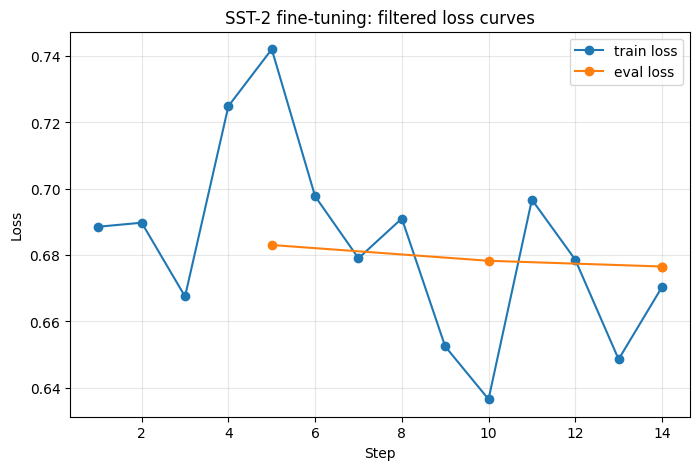

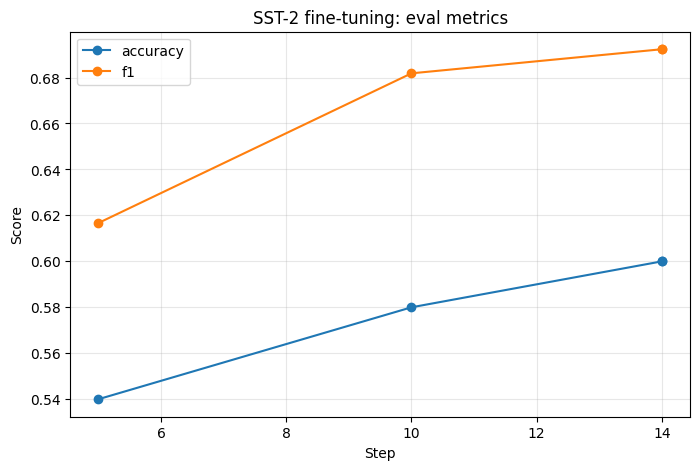

In [ ]:
# @title 8. Отфильтрованные логи + графики для SST-2
import matplotlib.pyplot as plt
import pandas as pd

log_df = pd.DataFrame(trainer.state.log_history)

# Отдельно train / eval / итоговые summary-строки
train_logs = log_df.dropna(subset=["loss"]).copy() if "loss" in log_df.columns else pd.DataFrame()
eval_logs = log_df.dropna(subset=["eval_loss"]).copy() if "eval_loss" in log_df.columns else pd.DataFrame()
summary_logs = log_df.dropna(subset=["train_loss"]).copy() if "train_loss" in log_df.columns else pd.DataFrame()

print("=== Train logs ===")
if len(train_logs) > 0:
    cols = [c for c in ["step", "epoch", "loss", "grad_norm", "learning_rate"] if c in train_logs.columns]
    display(train_logs[cols].tail(10))
else:
    print("Нет train-логов")

print("\n=== Eval logs ===")
if len(eval_logs) > 0:
    cols = [c for c in ["step", "epoch", "eval_loss", "eval_accuracy", "eval_f1", "eval_runtime"] if c in eval_logs.columns]
    display(eval_logs[cols].tail(10))
else:
    print("Нет eval-логов")

print("\n=== Summary logs ===")
if len(summary_logs) > 0:
    cols = [c for c in ["train_runtime", "train_samples_per_second", "train_steps_per_second", "train_loss", "epoch"] if c in summary_logs.columns]
    display(summary_logs[cols].tail(10))
else:
    print("Нет summary-логов")

# 1. Loss curves
plt.figure(figsize=(8, 5))

if len(train_logs) > 0:
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="train loss")

if len(eval_logs) > 0:
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="o", label="eval loss")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("SST-2 fine-tuning: filtered loss curves")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 2. Eval metrics
metric_cols = [c for c in ["eval_accuracy", "eval_f1"] if c in eval_logs.columns]

if len(eval_logs) > 0 and len(metric_cols) > 0:
    plt.figure(figsize=(8, 5))
    for col in metric_cols:
        plt.plot(eval_logs["step"], eval_logs[col], marker="o", label=col.replace("eval_", ""))
    plt.xlabel("Step")
    plt.ylabel("Score")
    plt.title("SST-2 fine-tuning: eval metrics")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    print("Нет eval-метрик для графика")

In [ ]:
# @title 9. Несколько предсказаний модели
sample_texts = [
    "This movie was surprisingly touching and well-acted.",
    "I regret wasting two hours on this boring film.",
    "The plot is simple, but the characters are charming.",
]

inputs = tokenizer(sample_texts, truncation=True, padding=True, return_tensors="pt").to(model.device)

with torch.no_grad():
    outputs = model(**inputs)
    preds = outputs.logits.argmax(dim=-1).cpu().numpy()

for text, pred in zip(sample_texts, preds):
    print(f"TEXT: {text}")
    print(f"PRED: {id2label[int(pred)]}")
    print()

TEXT: This movie was surprisingly touching and well-acted.
PRED: POSITIVE

TEXT: I regret wasting two hours on this boring film.
PRED: POSITIVE

TEXT: The plot is simple, but the characters are charming.
PRED: POSITIVE



### Домашнее задание для той же задачи

Возьмите **один** из датасетов:
- `imdb`
- `ag_news`

Что надо поменять:
1. колонки текста и label,
2. число классов,
3. метрику (для `ag_news` лучше macro-F1 + accuracy).

Подсказка:
- `imdb` — бинарная классификация, похоже на SST-2
- `ag_news` — 4 класса

In [ ]:
# @title 10. Заготовка для домашки: text classification на другом датасете
# Пример: раскомментируйте и адаптируйте под imdb или ag_news

# hw_raw = load_dataset("imdb")
# print(hw_raw)
# print(hw_raw["train"][0])

# def preprocess_hw(batch):
#     return tokenizer(batch["text"], truncation=True, max_length=256)

# hw_tok = hw_raw.map(preprocess_hw, batched=True)

# num_labels = 2  # imdb -> 2, ag_news -> 4
# hw_model = AutoModelForSequenceClassification.from_pretrained(
#     model_checkpoint,
#     num_labels=num_labels,
# )

# print(hw_model)

## Часть B. Token classification / NER: CoNLL-2003

Теперь другая задача: каждому токену надо присвоить тег сущности.

Примеры тегов:
- `B-PER`, `I-PER`
- `B-ORG`, `I-ORG`
- `B-LOC`, `I-LOC`
- `O`

Мы используем `AutoModelForTokenClassification`.

In [ ]:
# @title 11. Загружаем CoNLL-2003 и смотрим примеры
ner_raw = load_dataset("eriktks/conll2003", revision="refs/convert/parquet")
print(ner_raw)

label_names = ner_raw["train"].features["ner_tags"].feature.names
print("NER labels:", label_names)

for i in range(2):
    ex = ner_raw["train"][i]
    print(f"\n--- example {i} ---")
    print("tokens:", ex["tokens"])
    print("tags:  ", [label_names[t] for t in ex["ner_tags"]])

conll2003/train/0000.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/312k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/283k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})
NER labels: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']

--- example 0 ---
tokens: ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']
tags:   ['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']

--- example 1 ---
tokens: ['Peter', 'Blackburn']
tags:   ['B-PER', 'I-PER']


In [ ]:
# @title 12. Токенизатор и выравнивание NER-меток по subwords
ner_checkpoint = "bert-base-cased"  # для NER cased часто работает лучше
ner_tokenizer = AutoTokenizer.from_pretrained(ner_checkpoint)

def tokenize_and_align_labels(examples):
    tokenized = ner_tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
        max_length=128,
    )

    aligned_labels = []

    for i, labels in enumerate(examples["ner_tags"]):
        word_ids = tokenized.word_ids(batch_index=i)
        previous_word_id = None
        label_ids = []

        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)  # special tokens do not contribute to loss
            elif word_id != previous_word_id:
                label_ids.append(labels[word_id])  # first subtoken gets the original label
            else:
                label_ids.append(-100)  # ignore continuation subtokens for simplicity
            previous_word_id = word_id

        aligned_labels.append(label_ids)

    tokenized["labels"] = aligned_labels
    return tokenized

ner_tokenized = ner_raw.map(tokenize_and_align_labels, batched=True)
print(ner_tokenized)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 3453
    })
})


In [ ]:
# @title 13. Загружаем BERT c token classification head и печатаем модель
num_ner_labels = len(label_names)

ner_model = AutoModelForTokenClassification.from_pretrained(
    ner_checkpoint,
    num_labels=num_ner_labels,
    id2label={i: name for i, name in enumerate(label_names)},
    label2id={name: i for i, name in enumerate(label_names)},
)

print(ner_model)
print("\nClassifier head:")
print(ner_model.classifier)

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized beca

BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, el

In [ ]:
# @title 14. Метрика для NER
seqeval = evaluate.load("seqeval")

def compute_metrics_ner(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    true_predictions = []
    true_labels = []

    for pred_seq, label_seq in zip(preds, labels):
        cur_preds = []
        cur_labels = []
        for p, l in zip(pred_seq, label_seq):
            if l != -100:
                cur_preds.append(label_names[p])
                cur_labels.append(label_names[l])
        true_predictions.append(cur_preds)
        true_labels.append(cur_labels)

    metrics = seqeval.compute(predictions=true_predictions, references=true_labels)

    return {
        "precision": metrics["overall_precision"],
        "recall": metrics["overall_recall"],
        "f1": metrics["overall_f1"],
        "accuracy": metrics["overall_accuracy"],
    }

In [ ]:
# @title 15. Fine-tuning on CoNLL-2003
ner_data_collator = DataCollatorForTokenClassification(tokenizer=ner_tokenizer)

ner_training_args = TrainingArguments(
    output_dir="./bert-conll2003",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    disable_tqdm=True,
)

ner_trainer = Trainer(
    model=ner_model,
    args=ner_training_args,
    train_dataset=ner_tokenized["train"],
    eval_dataset=ner_tokenized["validation"],
    processing_class=ner_tokenizer,
    data_collator=ner_data_collator,
    compute_metrics=compute_metrics_ner,
)

ner_trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.043851,0.039211,0.932753,0.939353,0.936042,0.989264
2,0.018546,0.035742,0.940488,0.947776,0.944118,0.990394


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1756, training_loss=0.07148979386582054, metrics={'train_runtime': 356.5626, 'train_samples_per_second': 78.758, 'train_steps_per_second': 4.925, 'total_flos': 700358414768136.0, 'train_loss': 0.07148979386582054, 'epoch': 2.0})

In [ ]:
# @title 16. Оценка на validation
ner_metrics = ner_trainer.evaluate()
ner_metrics

In [ ]:
# @title 17. Несколько предсказаний NER
example = ner_raw["validation"][0]
tokens = example["tokens"]

inputs = ner_tokenizer(
    tokens,
    is_split_into_words=True,
    return_tensors="pt",
    truncation=True,
).to(ner_model.device)

with torch.no_grad():
    outputs = ner_model(**inputs)
    pred_ids = outputs.logits.argmax(dim=-1)[0].cpu().tolist()

word_ids = inputs.word_ids(batch_index=0)

predicted_labels = []
seen = set()
for token_idx, word_id in enumerate(word_ids):
    if word_id is None or word_id in seen:
        continue
    seen.add(word_id)
    predicted_labels.append((tokens[word_id], label_names[pred_ids[token_idx]]))

print("Token -> predicted label")
for token, label in predicted_labels:
    print(f"{token:15s} {label}")

### Домашнее задание для той же задачи

Возьмите **один** из датасетов:
- `wnut_17`
- `wikiann` (например, можно попробовать русский или другой язык)

Что надо сделать:
1. понять, как называются колонки с токенами и тегами;
2. адаптировать функцию `tokenize_and_align_labels`;
3. обучить модель и сравнить результаты с CoNLL-2003.


## Вопросы для самопроверки

1. Почему для классификации текста удобно использовать `[CLS]`-представление?
2. Чем отличаются `AutoModelForSequenceClassification` и `AutoModelForTokenClassification`?
3. Зачем в NER мы используем `-100`?
4. Почему для NER часто лучше `bert-base-cased`?
5. Что меняется, если взять другой датасет, но ту же задачу?

## Часть C. Sentence pair classification: MRPC

Теперь задача, где на вход подаются **два предложения**.

В MRPC нужно определить, являются ли два предложения парафразами:
- `0` — not equivalent
- `1` — equivalent

Токенизатор получает **сразу два текста**:
```python
tokenizer(sentence1, sentence2, truncation=True)
```

In [ ]:
# @title 18. Загружаем MRPC и смотрим примеры
pair_raw = load_dataset("glue", "mrpc")
print(pair_raw)

for split in ["train", "validation"]:
    print(f"\n--- {split} examples ---")
    for i in range(2):
        ex = pair_raw[split][i]
        print(f"[{i}] sentence1 = {ex['sentence1']}")
        print(f"    sentence2 = {ex['sentence2']}")
        print(f"    label     = {ex['label']}")
        print()

In [ ]:
# @title 19. Токенизация sentence pairs
pair_checkpoint = "bert-base-uncased"
pair_tokenizer = AutoTokenizer.from_pretrained(pair_checkpoint)

def preprocess_pair(batch):
    return pair_tokenizer(
        batch["sentence1"],
        batch["sentence2"],
        truncation=True,
        max_length=128,
    )

pair_tok = pair_raw.map(preprocess_pair, batched=True)
print(pair_tok)

In [ ]:
# @title 20. Загружаем BERT c головой для sentence pair classification
pair_id2label = {0: "NOT_EQUIVALENT", 1: "EQUIVALENT"}
pair_label2id = {v: k for k, v in pair_id2label.items()}

pair_model = AutoModelForSequenceClassification.from_pretrained(
    pair_checkpoint,
    num_labels=2,
    id2label=pair_id2label,
    label2id=pair_label2id,
)

print(pair_model)
print("\nClassifier head:")
print(pair_model.classifier)

In [ ]:
# @title 21. Метрики и fine-tuning для MRPC
pair_accuracy = evaluate.load("accuracy")
pair_f1 = evaluate.load("f1")

def compute_metrics_pair(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = pair_accuracy.compute(predictions=preds, references=labels)["accuracy"]
    f1 = pair_f1.compute(predictions=preds, references=labels, average="binary")["f1"]
    return {"accuracy": acc, "f1": f1}

pair_collator = DataCollatorWithPadding(tokenizer=pair_tokenizer)

pair_args = TrainingArguments(
    output_dir="./bert-mrpc",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    disable_tqdm=True,
)

pair_trainer = Trainer(
    model=pair_model,
    args=pair_args,
    train_dataset=pair_tok["train"],
    eval_dataset=pair_tok["validation"],
    processing_class=pair_tokenizer,
    data_collator=pair_collator,
    compute_metrics=compute_metrics_pair,
)

pair_trainer.train()
pair_metrics = pair_trainer.evaluate()
pair_metrics

In [ ]:
# @title 22. Несколько предсказаний для sentence pair classification
pair_examples = [
    (
        "The company released a new smartphone yesterday.",
        "A new phone was launched by the company yesterday."
    ),
    (
        "He missed the train because he overslept.",
        "He arrived early and caught the first train."
    ),
]

enc = pair_tokenizer(
    [x[0] for x in pair_examples],
    [x[1] for x in pair_examples],
    truncation=True,
    padding=True,
    return_tensors="pt",
).to(pair_model.device)

with torch.no_grad():
    logits = pair_model(**enc).logits
    preds = logits.argmax(dim=-1).cpu().tolist()

for (s1, s2), pred in zip(pair_examples, preds):
    print("SENTENCE 1:", s1)
    print("SENTENCE 2:", s2)
    print("PRED:", pair_id2label[pred])
    print()

### Домашнее задание для sentence pair classification

Возьмите **один** из датасетов:
- `glue/rte`
- `glue/qnli`

Что нужно сделать:
1. найти названия колонок с двумя текстами и меткой;
2. адаптировать токенизацию:
   ```python
   tokenizer(text1, text2, truncation=True)
   ```
3. обучить BERT и измерить качество;
4. сравнить задачу с MRPC: чем отличается смысл метки?

Подсказка:
- **RTE** — textual entailment,
- **QNLI** — question + sentence, нужно определить, содержит ли sentence ответ на question.

## Часть D. Extractive Question Answering: SQuAD

Теперь задача извлечения ответа из контекста.

Модель получает:
- вопрос,
- контекст,

и должна предсказать **начальную и конечную позицию ответа** в тексте.

Для этого используется голова:
```python
AutoModelForQuestionAnswering
```

In [ ]:
# @title 23. Импорт модели для QA
from transformers import AutoModelForQuestionAnswering, default_data_collator

In [ ]:
# @title 24. Загружаем SQuAD и смотрим примеры
qa_raw = load_dataset("squad")
print(qa_raw)

for i in range(2):
    ex = qa_raw["train"][i]
    print(f"\n--- example {i} ---")
    print("question:", ex["question"])
    print("context: ", ex["context"][:400], "...")
    print("answers: ", ex["answers"])

In [ ]:
# @title 25. Токенизация SQuAD и построение start/end positions
qa_checkpoint = "bert-base-uncased"
qa_tokenizer = AutoTokenizer.from_pretrained(qa_checkpoint)

max_length = 384
doc_stride = 128

def preprocess_qa_train(examples):
    questions = [q.strip() for q in examples["question"]]
    inputs = qa_tokenizer(
        questions,
        examples["context"],
        max_length=max_length,
        truncation="only_second",
        stride=doc_stride,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
    )

    offset_mapping = inputs["offset_mapping"]
    sample_map = inputs["overflow_to_sample_mapping"]

    start_positions = []
    end_positions = []

    for i, offsets in enumerate(offset_mapping):
        sample_idx = sample_map[i]
        answer = examples["answers"][sample_idx]
        start_char = answer["answer_start"][0]
        end_char = start_char + len(answer["text"][0])

        sequence_ids = inputs.sequence_ids(i)

        context_start = 0
        while sequence_ids[context_start] != 1:
            context_start += 1
        context_end = len(sequence_ids) - 1
        while sequence_ids[context_end] != 1:
            context_end -= 1

        if offsets[context_start][0] > end_char or offsets[context_end][1] < start_char:
            start_positions.append(0)
            end_positions.append(0)
        else:
            token_start = context_start
            while token_start <= context_end and offsets[token_start][0] <= start_char:
                token_start += 1
            start_positions.append(token_start - 1)

            token_end = context_end
            while token_end >= context_start and offsets[token_end][1] >= end_char:
                token_end -= 1
            end_positions.append(token_end + 1)

    inputs["start_positions"] = start_positions
    inputs["end_positions"] = end_positions
    return inputs

# Чтобы пример был достаточно быстрым для Colab, можно взять подмножество
qa_train_small = qa_raw["train"].select(range(3000))
qa_val_small = qa_raw["validation"].select(range(500))

qa_train_tok = qa_train_small.map(
    preprocess_qa_train,
    batched=True,
    remove_columns=qa_train_small.column_names,
)

qa_val_tok = qa_val_small.map(
    preprocess_qa_train,
    batched=True,
    remove_columns=qa_val_small.column_names,
)

print(qa_train_tok)
print(qa_val_tok)

In [ ]:
# @title 26. Загружаем BERT c QA head и печатаем модель
qa_model = AutoModelForQuestionAnswering.from_pretrained(qa_checkpoint)

print(qa_model)
print("\nQA outputs head:")
print(qa_model.qa_outputs)

In [ ]:
# @title 27. Fine-tuning на небольшом подмножестве SQuAD
qa_args = TrainingArguments(
    output_dir="./bert-squad-demo",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

qa_trainer = Trainer(
    model=qa_model,
    args=qa_args,
    train_dataset=qa_train_tok,
    eval_dataset=qa_val_tok,
    processing_class=qa_tokenizer,
    data_collator=default_data_collator,
)

qa_trainer.train()
qa_eval = qa_trainer.evaluate()
qa_eval

In [ ]:
# @title 28. Пример инференса на QA
qa_example = qa_raw["validation"][0]
question = qa_example["question"]
context = qa_example["context"]

inputs = qa_tokenizer(question, context, return_tensors="pt", truncation=True, max_length=384).to(qa_model.device)

with torch.no_grad():
    outputs = qa_model(**inputs)

start_idx = int(outputs.start_logits.argmax(dim=-1)[0])
end_idx = int(outputs.end_logits.argmax(dim=-1)[0])

tokens = inputs["input_ids"][0]
pred_answer = qa_tokenizer.decode(tokens[start_idx:end_idx+1], skip_special_tokens=True)

print("QUESTION:", question)
print("PREDICTED ANSWER:", pred_answer)
print("GOLD ANSWERS:", qa_example["answers"]["text"])

### Домашнее задание для QA

Возьмите **один** из датасетов:
- `squad_v2`
- `boolq`  *(это уже не extractive QA, а classification)*

Вопросы:
- почему extractive QA требует start/end logits;
- чем эта голова отличается от обычной классификации;
- почему для длинных контекстов нужен `stride`.